## 📌 Project Objective

Build a linear regression model to predict house prices affected by multiple features and this project would include,
- Data overview and analysis using EDA
- EDA charts and key insights
- Linear regression model to find the best fit regression line
- Model evaluation
- Overview of the project through key business and learning insights

### Data overveiw and analysis

In [35]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

#### Load the dataset

In [36]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\data\House Price India.csv")

In [37]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [38]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,...,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04
mean,6.762821e+09,42604.546412,3.379233,2.129557,2098.156851,1.509369e+04,1.502326,0.007661,0.232848,3.430399,...,1970.929817,90.930228,122033.064300,52.792843,-114.403996,1996.641836,12754.003078,2.012244,64.951433,5.388063e+05
std,6.237162e+03,67.343747,0.938655,0.769955,928.218740,3.792089e+04,0.540241,0.087196,0.765651,0.664047,...,29.491743,416.230218,19.081451,0.137525,0.141325,691.078387,26059.234785,0.817312,8.936129,3.672294e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010500e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.500000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

#### Remove unnecessary columns from the dataset

In [40]:
df = df.drop(['id','Date','Postal Code','living_area_renov','lot_area_renov'], axis=1)

#### Create house age and rennovation age

In [41]:
current_year = 2026

df['house_age'] = current_year - df['Built Year']

In [42]:
df['renovation_age'] = np.where(
    df['Renovation Year'] == 0,
    df['house_age'],                       # never renovated → same as house age
    current_year - df['Renovation Year']
)

In [43]:
# remove original columns
df = df.drop(['Built Year','Renovation Year'], axis=1)

In [45]:
# check
df.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Lattitude,Longitude,Number of schools nearby,Distance from the airport,Price,house_age,renovation_age
0,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,52.8878,-114.470,2,51,1400000,117,117
1,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,52.8852,-114.468,1,53,1200000,87,87
2,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,52.9532,-114.321,3,76,838000,25,25
3,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,52.9047,-114.485,1,51,805000,97,97
4,3,2.50,2600,4750,1.0,0,0,4,9,1700,900,52.9133,-114.590,1,67,790000,75,75


#### Distribution of house prices

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

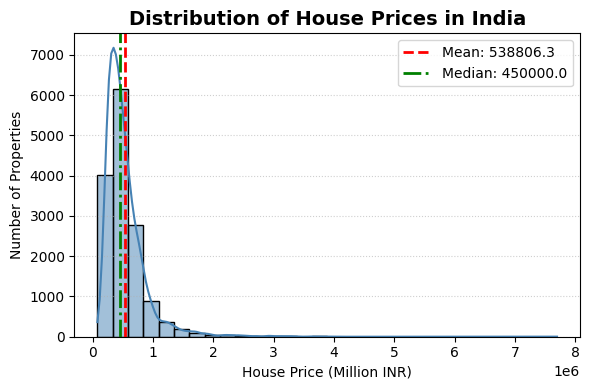

In [47]:
plt.figure(figsize=(6,4))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

# Central tendency
mean_price = df["Price"].mean()
median_price = df["Price"].median()

plt.axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_price:.1f}")
plt.axvline(median_price, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_price:.1f}")

# Labels & title
plt.title("Distribution of House Prices in India", fontsize=14, fontweight="bold")
plt.xlabel("House Price (Million INR)")
plt.ylabel("Number of Properties")

plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### House area vs price - Scatter plot

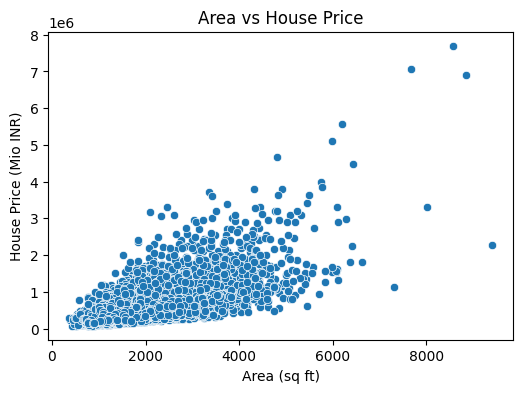

In [48]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Area of the house(excluding basement)"], y=df["Price"])
plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("House Price (Mio INR)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Correlation heatmap

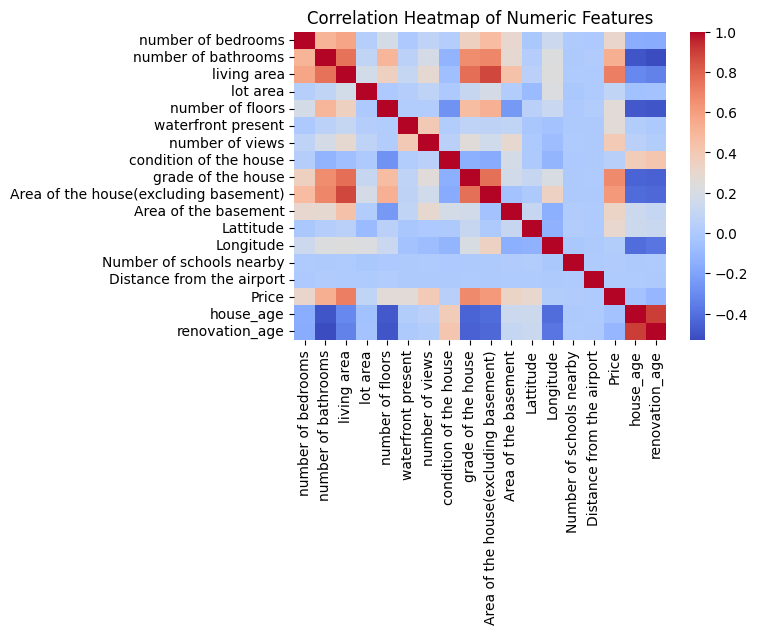

In [49]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), 
            cmap="coolwarm", 
            fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insights

- **Living area** has the **strongest positive correlation with Price** → biggest driver of house value.
- **Grade of the house** and **number of bathrooms** also show high positive correlation with Price → quality & usability matter.
- **Latitude** positively correlates with Price → certain locations/neighborhoods are more expensive.
- **House_age** and **renovation_age** show **negative correlation with Price** → older houses sell cheaper unless upgraded.
- **Bedrooms, floors, and living area** are highly correlated with each other → indicates multicollinearity (redundant size-related features).
- **Basement area** moderately increases price but less than above-ground living area.
- **Distance from airport** slightly negatively correlated → properties farther from airport tend to be costlier (less noise/pollution).
- **Waterfront and number of views** positively influence price but impact is smaller compared to living area and grade.

#### Feature selection

In [51]:
X = df.drop("Price",axis = 1)
y = df["Price"]

y = np.log(y)

#### Split the data

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#### Feature scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [56]:
y_pred = lr_model.predict(X_test)

#### Model evaluation

In [57]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

MAE:  0.19608566382614548
RMSE:  0.06542467074577614
R2:  0.7736436724284057


#### Actual vs predicted

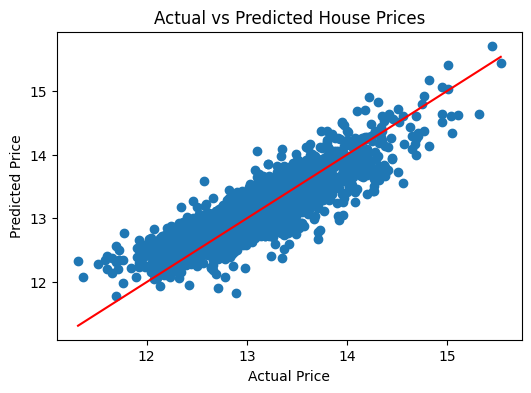

In [58]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\actual_vs_predicted_prices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Residual calculation

In [59]:
residuals = y_test - y_pred

#### Residual distribution

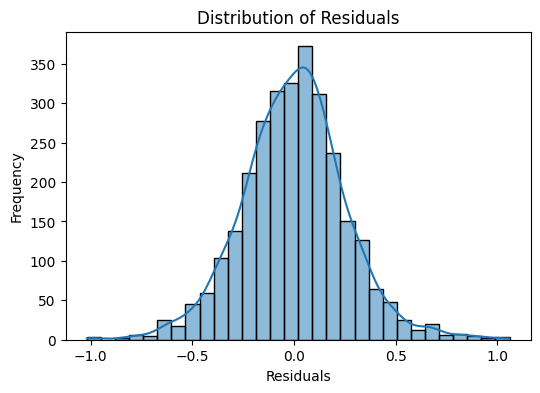

In [60]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Sitaram_Github\AI_ML_projects\01_linear_regression_house_price\images\residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 📌 Key insights and learning summary

### Linear Regression performance

- MAE: 0.196
- RMSE: 0.065
- R2: 0.77

### 🧠 Key Analytical Insights

#### Property characteristics (Primary drivers)

- Living area is the strongest predictor of house price.
- House grade/quality has very high positive correlation with price → construction quality strongly impacts valuation.
- Number of bathrooms positively influences price (usability factor).
- Above-ground usable area contributes more to pricing than lot/land area.
- Basement area adds value but less than the main living space.

#### Market behavior insight

- Price distribution is right-skewed, confirming a real estate market pattern.
- Majority homes belong to mid-price segment.
- A small number of luxury homes form high-price outliers.
- Houses with similar size can vary greatly in price due to quality, renovation, and location premium.

### 🏁 Conclusion

Multiple Linear Regression can successfully estimate housing prices when important real-estate factors such as size, quality, age, and location are properly engineered. Applying log transformation to price significantly improved model reliability by correcting skewed price distribution. The model provides interpretable relationships between housing features and price, though prediction accuracy slightly reduces for luxury properties due to market perception, neighborhood prestige, and non-quantifiable factors.    

### Key business takeaway:
                                                                                                        
House pricing is primarily driven by usable living space, construction quality, and location, while land size and nearby amenities play a smaller role.
Predictive pricing models can help real-estate platforms, banks, and buyers estimate fair property values, reduce valuation bias, and support data-driven loan approval, investment, and listing decisions.